# HS4002 Week 3

## Data Preparation

This week we need the `scipy` library for skewness and kurtosis statistics.

Make sure `gss2022_mini.csv` is in the same folder.

In [11]:
# !pip install pandas numpy scipy plotnine

import pandas as pd
import numpy as np
import plotnine as p9
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import skew, kurtosis

## Select variables of interest

In [30]:
raw_df = pd.read_csv("gss2022_mini.csv")

chosen_variables = [
	"id", "yrlvmus" , 'yrartxbt', 'yrmovie', 'yrcreat', 'income16', 'prestg10']
	
df = raw_df[chosen_variables].copy()

## Remove all rows with missing values

In [31]:
df = df.dropna()

## Recode categorical variables into binary variables

`1 = attended / participated`, `0 = did not`. Refer to the GSS Codebook for coding.

In [32]:
df['binary_lvmus']  = np.where(df['yrlvmus']  == 1, 1, 0)
df['binary_artxbt'] = np.where(df['yrartxbt']  == 1, 1, 0)
df['binary_movie']  = np.where(df['yrmovie']  == 1, 1, 0)
df['binary_creat']  = np.where(df['yrcreat']  == 1, 1, 0)

## Recode income into a continuous variable

`income16` is an ordinal variable (income brackets). Standard practice assigns each person the midpoint of their bracket. In Python, a dictionary lookup is much cleaner than nested `ifelse()` calls.

In [33]:
# Recode income16 (ordinal brackets) to continuous midpoint values
# This replaces the deeply nested ifelse() chain from the R version
income_map = {
	1: 500,    2: 2000,    3: 3500,    4: 4500,    5: 5500,    6: 6500,    7: 7500,    8: 9000,    9: 11250,
 10: 13750,    11: 16250,    12: 18750,    13: 21250,    14: 23750,    15: 27500,    16: 32500,    17: 37500,
 18: 45000,    19: 55000,    20: 67500,   21: 82500,    22: 100000,    23: 120000,    24: 140000,    25: 160000,    26: 250000
}
df['income_cont'] = df['income16'].map(income_map)
df["income_cont"].mean()

np.float64(87334.82142857143)

## Make a new variable for the omnivorousness index

Sum the four binary cultural participation variables.

In [16]:
df = df.assign(
	omni=(
		df['binary_lvmus']
		+ df['binary_artxbt']
		+ df['binary_movie']
		+ df['binary_creat']
	)
)
df["omni"].value_counts()

omni
2    201
1    183
0    155
3    124
4     65
Name: count, dtype: int64

## Produce 3 samples

Sizes n = 30 (small), n = 100 (medium), and n = 500 (large).

In [17]:
np.random.seed(47)
df_small  = df.sample(n=30,  random_state=47)
df_medium = df.sample(n=100, random_state=47)
df_large  = df.sample(n = 500, random_state = 47)

# Compare Distributions of Categorical Variables Across Samples

## What proportion attended live music last year?

In [19]:
print("Small:")
print(df_small['binary_lvmus'].value_counts(normalize=True))
print("Medium:")
print(df_medium['binary_lvmus'].value_counts(normalize=True))
print("Large:")
print(df_large['binary_lvmus'].value_counts(normalize=True))
print("Full GSS")
print(df['binary_lvmus'].value_counts(normalize=True))

Small:
binary_lvmus
1    0.6
0    0.4
Name: proportion, dtype: float64
Medium:
binary_lvmus
1    0.6
0    0.4
Name: proportion, dtype: float64
Large:
binary_lvmus
1    0.524
0    0.476
Name: proportion, dtype: float64
Full GSS
binary_lvmus
1    0.523352
0    0.476648
Name: proportion, dtype: float64


## What proportion visited an art exhibit last year?

## Plot a bar chart for movie-watching (large sample)

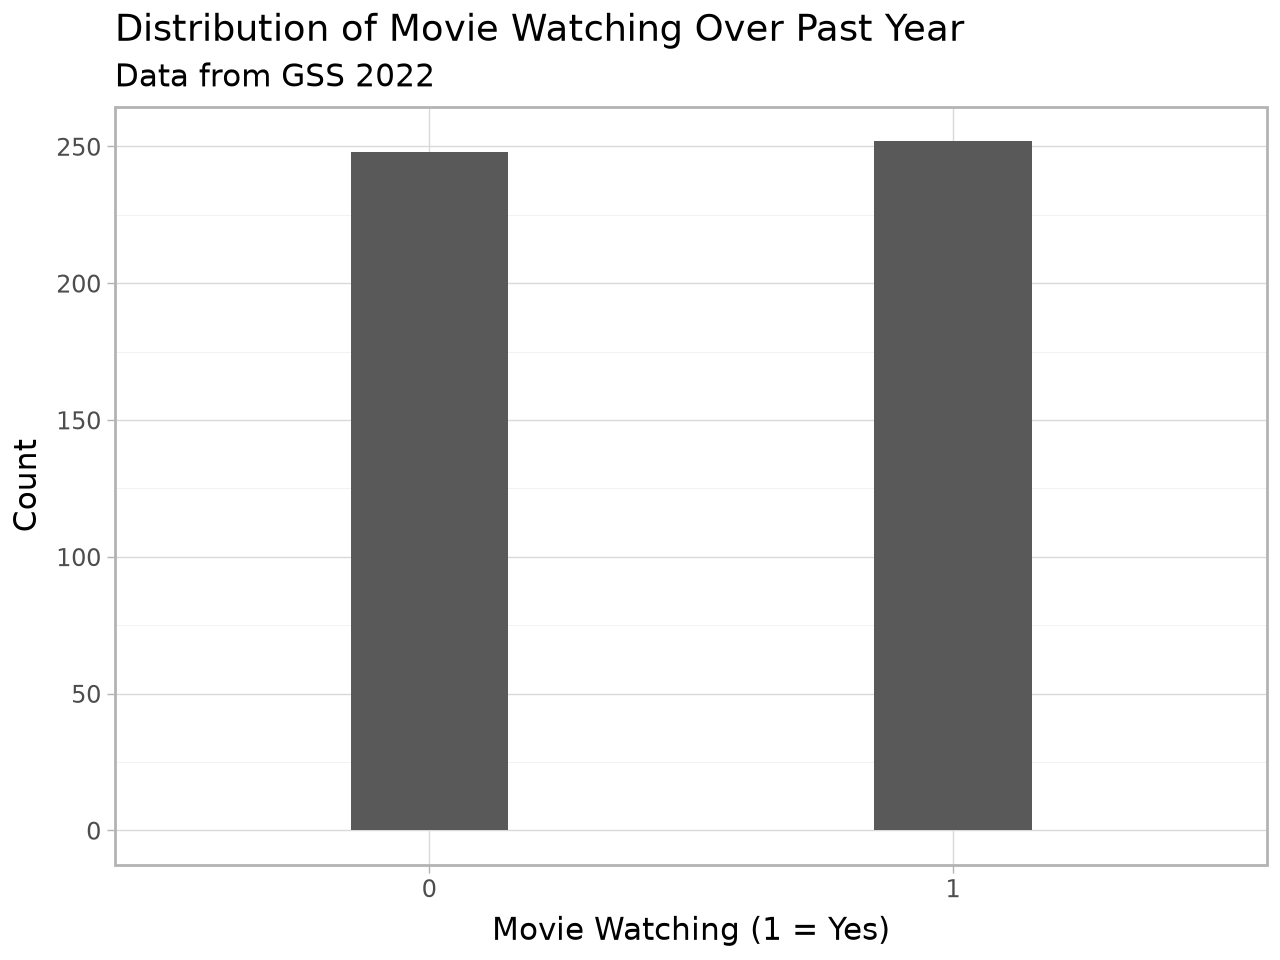

In [20]:
p = (
	p9.ggplot(df_large) +
	p9.geom_bar(p9.aes(x='factor(binary_movie)'), width=0.3) +
	p9.theme_light() +
	p9.labs(x='Movie Watching (1 = Yes)', y='Count',
			title='Distribution of Movie Watching Over Past Year',
			subtitle='Data from GSS 2022')
)
p.save('bar_movies.png', width=15, height=10.5, units='cm')
p

## Plot a histogram of the omnivorousness index

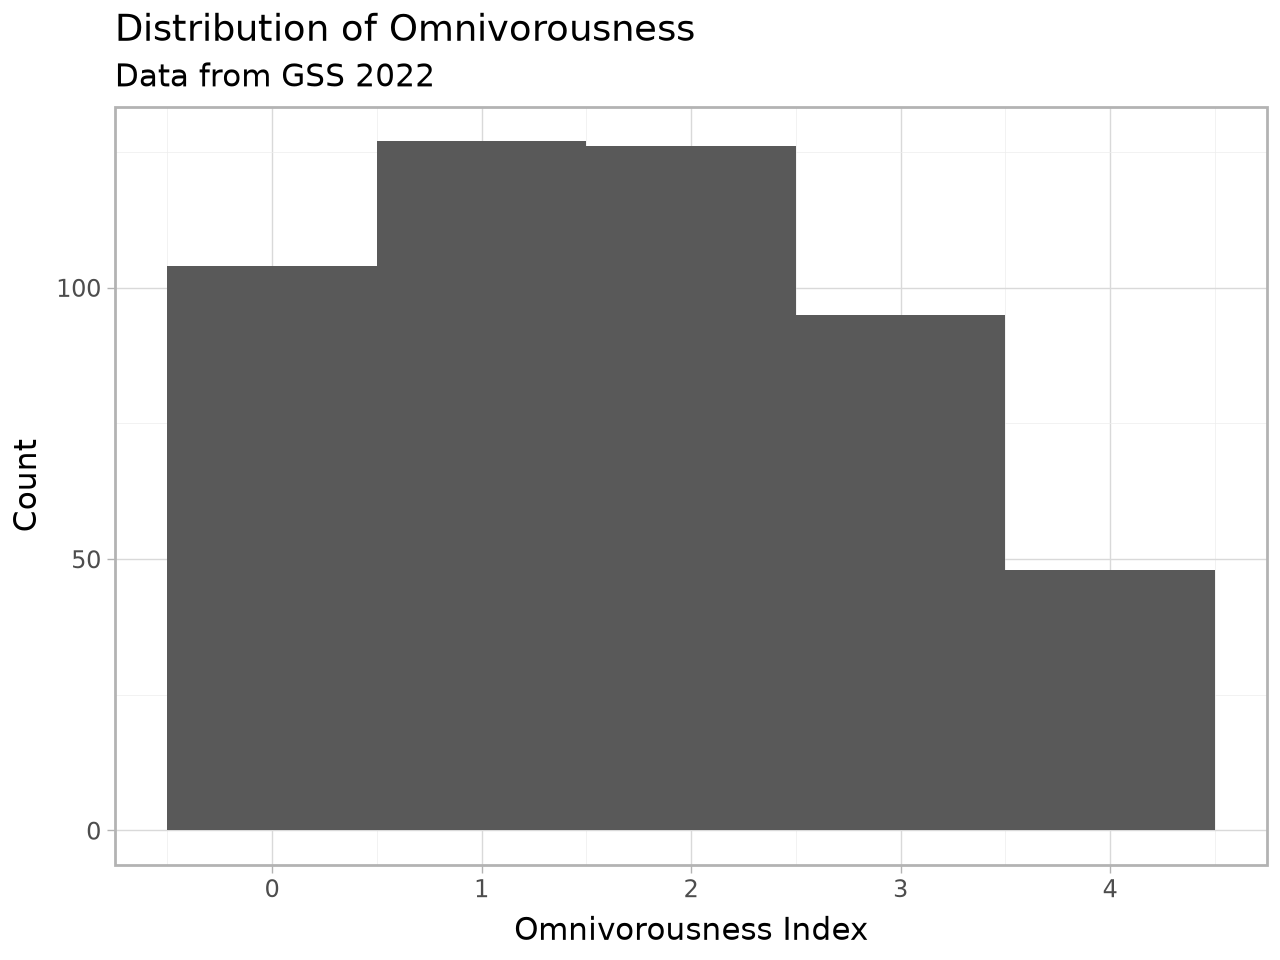

In [21]:
p = (
	p9.ggplot(df_large) +
	p9.geom_histogram(p9.aes(x='omni'), binwidth=1) +
	p9.theme_light() +
	p9.labs(x='Omnivorousness Index', y='Count',
			title='Distribution of Omnivorousness',
			subtitle='Data from GSS 2022')
)
p.save('hist_omni.png', width=15, height=10.5, units='cm')
p

# Compare Distributions of Two Continuous Variables

We compare household income with occupational prestige using the large sample.

## Scale the variables

Standardize so both variables are on the same scale (mean = 0, SD = 1). Equivalent to R's `scale()`.

In [27]:
df_large = df_large.copy()
df_large['scaled_income'] = (df_large['income_cont'] - df_large['income_cont'].mean()) / df_large['income_cont'].std()
df_large['scaled_prestg'] = (df_large['prestg10'] - df_large['prestg10'].mean()) / df_large['prestg10'].std()

## Plot the distributions of each variable

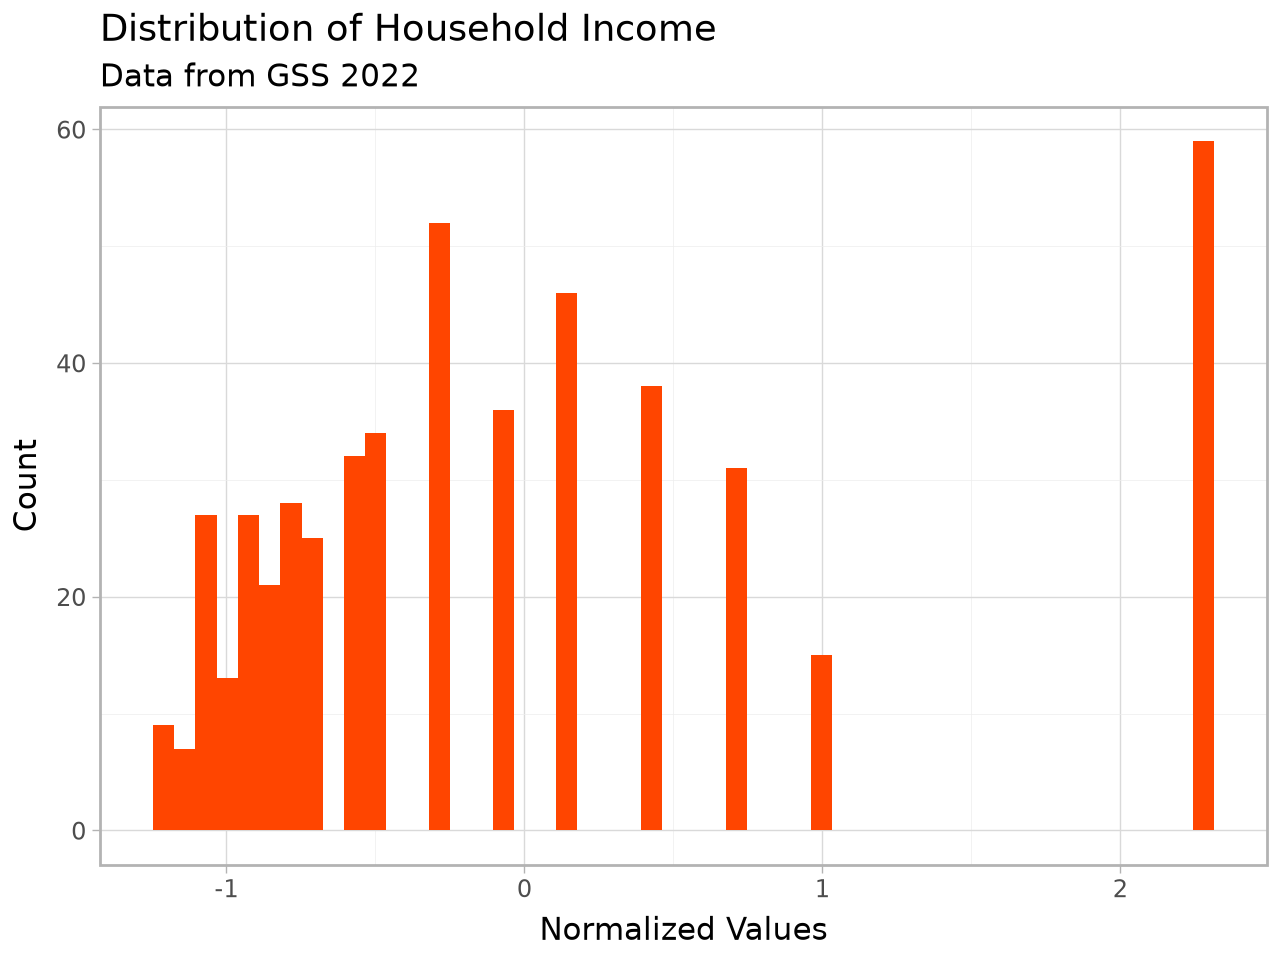

In [28]:
p = (
	p9.ggplot(df_large) +
	p9.geom_histogram(p9.aes(x='scaled_income'), bins=50, fill='orangered') +
	p9.theme_light() +
	p9.labs(x='Normalized Values', y='Count',
			title='Distribution of Household Income', subtitle='Data from GSS 2022')
)
p.save('hist_income.png', width=15, height=10.5, units='cm')
p

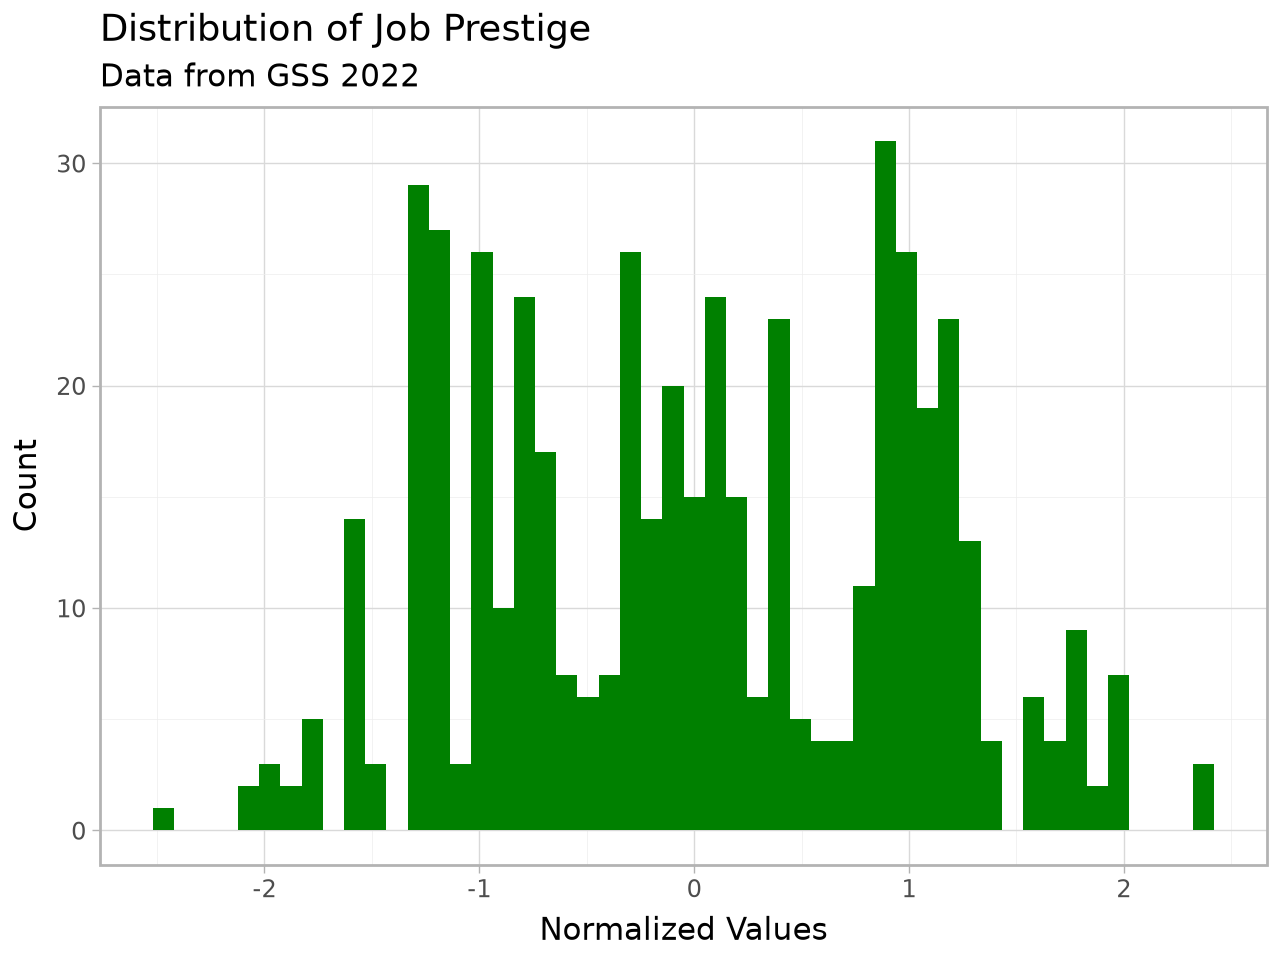

In [29]:
p = (
	p9.ggplot(df_large) +
	p9.geom_histogram(p9.aes(x='scaled_prestg'), bins=50, fill='green') +
	p9.theme_light() +
	p9.labs(x='Normalized Values', y='Count',
			title='Distribution of Job Prestige', subtitle='Data from GSS 2022')
)
p.save('hist_income.png', width=15, height=10.5, units='cm')
p

## Calculate Skewness of each variable

Skewness > 0 is right-skewed (long right tail); < 0 is left-skewed.

In [ ]:
print('Skewness of Income (scaled):',  skew(df_large['scaled_income']))

## Calculate Kurtosis of each variable

`scipy.stats.kurtosis` with `fisher=False` gives Pearson kurtosis (same as R's `moments::kurtosis`). A normal distribution has kurtosis ≈ 3 (mesokurtic); > 3 is leptokurtic.

In [ ]:
# fisher=False gives Pearson kurtosis — equivalent to R's moments::kurtosis()
print('Kurtosis of Income (scaled):',  kurtosis(df_large['scaled_income'], fisher=False))